In [1]:
import gc
import json
from pathlib import Path

import anndata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scvi
import torch

import sys
sys.path.append("../..")  # so `from app.task import ...` resolves; adjust if needed

from app.task import (
    create_scvi_model,
    get_architecture,
    get_loss_metrics,
    get_weights,
    read_json,
    set_weights,
)

torch.set_float32_matmul_precision("high")


c:\Users\virgi\anaconda3\envs\flwr-scvi\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
MODEL_FILE_PATH = "model_federated"  # from pyproject.toml
RESULTS_ROOT = Path("../../../fairness_results")  # adjust to your actual cwd

RUN_TAG = f"{MODEL_FILE_PATH}_qffl_q0p0"   # FedAvg baseline checkpoint
CHECKPOINT_DIR = RESULTS_ROOT / RUN_TAG

CLIENT_FOLDER_TEMPLATE = "../../../data_federated/data_client_{partition_id}"  # adjust to your actual cwd
TOP2K_GENES_FILE = "top2k_genes.json"
ALL_TECHS_FILE = "all_techs.json"
N_CLIENTS = 7  # from pyproject.toml: options.num-supernodes

# How many local epochs to fine-tune each client's copy for. A short list lets
# you see whether the gap closes gradually (real signal) or all at once /
# not at all (less informative -- try a few values before concluding).
FT_EPOCHS_TO_TRY = [3, 5, 10]

assert CHECKPOINT_DIR.exists(), f"Checkpoint dir not found: {CHECKPOINT_DIR}"


In [3]:
global_model = scvi.model.SCVI.load(str(CHECKPOINT_DIR))
global_weights = get_weights(global_model)
print(f"Loaded checkpoint from {CHECKPOINT_DIR}")
print(f"Number of parameter arrays: {len(global_weights)}")

del global_model
gc.collect()


INFO     File ..\..\..\fairness_results\model_federated_qffl_q0p0\model.pt already downloaded                      


Loaded checkpoint from ..\..\..\fairness_results\model_federated_qffl_q0p0
Number of parameter arrays: 25


52

In [4]:
def load_client_data(client_id: int, client_folder_template: str, hvg_list: list[str]):
    client_folder = Path(client_folder_template.format(partition_id=client_id))
    train = anndata.read_h5ad(client_folder / "train.h5ad")
    train = train[:, hvg_list].copy()
    valid = anndata.read_h5ad(client_folder / "valid.h5ad")
    valid = valid[:, hvg_list].copy()
    return train, valid


rows = []

for client_id in range(N_CLIENTS):
    client_folder = Path(CLIENT_FOLDER_TEMPLATE.format(partition_id=client_id))
    hvg_list = read_json(client_folder / TOP2K_GENES_FILE)
    batch_list = read_json(client_folder / ALL_TECHS_FILE)

    adata_train, adata_valid = load_client_data(client_id, CLIENT_FOLDER_TEMPLATE, hvg_list)
    tech = adata_train.obs["tech"].unique().tolist()

    arch_cfg = get_architecture({})  # uses defaults; pass your run_config dict if non-default
    model = create_scvi_model(adata_train, batch_list, arch_cfg)
    set_weights(model, global_weights)

    # --- Baseline (pre fine-tuning) ---
    baseline_train_metrics = get_loss_metrics(model, adata_train)
    baseline_valid_metrics = get_loss_metrics(model, adata_valid)

    row = {
        "client_id": client_id,
        "tech": tech,
        "n_train": adata_train.n_obs,
        "n_valid": adata_valid.n_obs,
        "valid_loss_before": baseline_valid_metrics["loss"],
        "valid_loss_per_1k_counts_before": baseline_valid_metrics["loss_per_1k_counts"],
    }

    # --- Fine-tune for each epoch budget, evaluating after each ---
    for ft_epochs in FT_EPOCHS_TO_TRY:
        model.train(max_epochs=ft_epochs, train_size=1.0)
        ft_valid_metrics = get_loss_metrics(model, adata_valid)
        row[f"valid_loss_after_{ft_epochs}ep"] = ft_valid_metrics["loss"]
        row[f"valid_loss_per_1k_counts_after_{ft_epochs}ep"] = ft_valid_metrics["loss_per_1k_counts"]

    rows.append(row)
    print(f"client {client_id} ({tech}): "
          f"raw {row['valid_loss_before']:.1f} -> {row[f'valid_loss_after_{FT_EPOCHS_TO_TRY[-1]}ep']:.1f}  |  "
          f"norm {row['valid_loss_per_1k_counts_before']:.2f} -> "
          f"{row[f'valid_loss_per_1k_counts_after_{FT_EPOCHS_TO_TRY[-1]}ep']:.2f}")

    del model, adata_train, adata_valid
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

results_df = pd.DataFrame(rows).sort_values("n_valid")
results_df


c:\Users\virgi\anaconda3\envs\flwr-scvi\Lib\site-packages\scvi\data\fields\_base_field.py:63: UserWarning: adata.layers[counts] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


c:\Users\virgi\anaconda3\envs\flwr-scvi\Lib\site-packages\scvi\module\_vae.py:573: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)
c:\Users\virgi\anaconda3\envs\flwr-scvi\Lib\site-packages\scvi\data\fields\_base_field.py:63: UserWarning: adata.layers[counts] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)
c:\Users\virgi\anaconda3\envs\flwr-scvi\Lib\site-packages\scvi\module\_vae.py:573: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Expe

Epoch 1/3:   0%|          | 0/3 [00:00<?, ?it/s]

c:\Users\virgi\anaconda3\envs\flwr-scvi\Lib\site-packages\scvi\module\_vae.py:573: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)


...

Epoch 10/10: 100%|██████████| 10/10 [00:05<00:00,  1.85it/s, v_num=1, train_loss=2.54e+3]

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 10/10: 100%|██████████| 10/10 [00:05<00:00,  1.79it/s, v_num=1, train_loss=2.54e+3]
client 6 (['smarter']): raw 3109.7 -> 2696.8  |  norm 16.88 -> 14.64


c:\Users\virgi\anaconda3\envs\flwr-scvi\Lib\site-packages\scvi\module\_vae.py:573: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)


,client_id,tech,n_train,n_valid,valid_loss_before,valid_loss_per_1k_counts_before,valid_loss_after_3ep,valid_loss_per_1k_counts_after_3ep,valid_loss_after_5ep,valid_loss_per_1k_counts_after_5ep,valid_loss_after_10ep,valid_loss_per_1k_counts_after_10ep
1,1,[fluidigmc1],510,128,5374.739258,15.541376,4696.872070,13.581283,4431.277832,12.813302,4314.733398,12.476307
0,0,[celseq],803,201,1196.973145,603.148268,1022.030151,514.995443,981.336853,494.490311,962.963379,485.232018
5,5,[inDrop4],1042,261,661.496521,565.857837,628.673889,537.780678,619.018921,529.521618,613.774963,525.035828
6,6,[smarter],1194,298,3109.743408,16.879751,2779.058838,15.084789,2733.287354,14.836340,2696.756592,14.638050
3,3,[inDrop2],1379,345,533.627991,601.001070,512.808899,577.553469,505.811371,569.672470,500.005249,563.133297
2,2,[inDrop1],1550,387,583.885071,509.718965,567.251892,495.198562,559.319397,488.273666,554.246338,483.844996
4,4,[inDrop3],2884,721,566.378540,400.642144,548.377319,387.908527,540.962952,382.663787,533.607239,377.460538


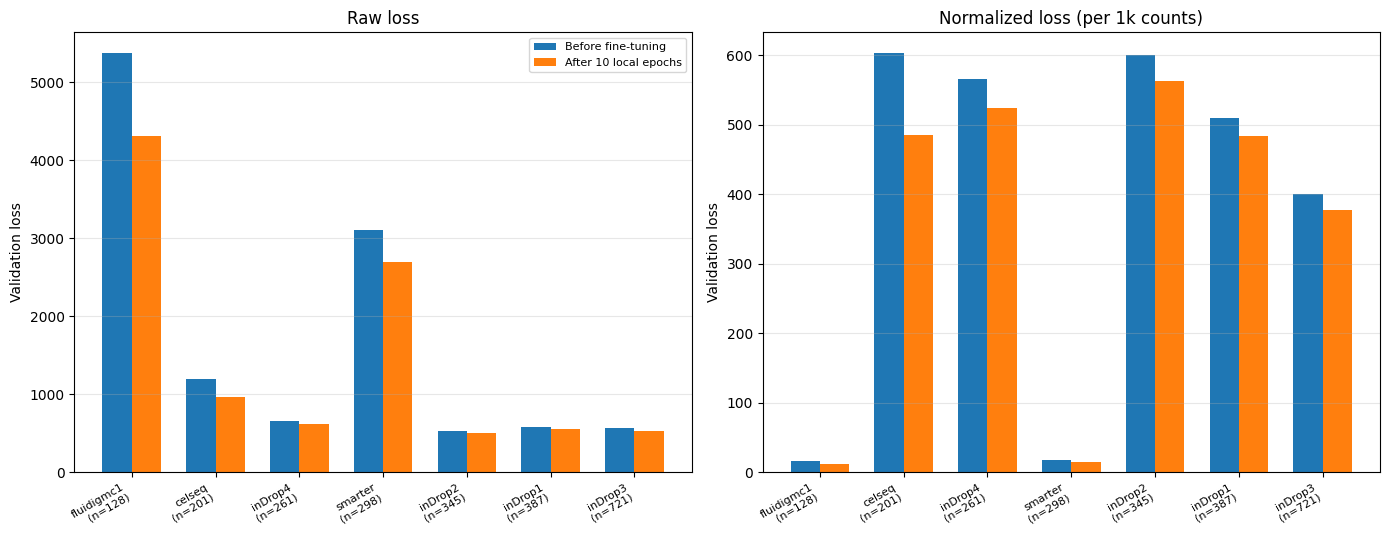

In [5]:
last_ft = FT_EPOCHS_TO_TRY[-1]
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

x = np.arange(len(results_df))
width = 0.35

for ax, before_col, after_col, title in [
    (axes[0], "valid_loss_before", f"valid_loss_after_{last_ft}ep", "Raw loss"),
    (axes[1], "valid_loss_per_1k_counts_before", f"valid_loss_per_1k_counts_after_{last_ft}ep",
     "Normalized loss (per 1k counts)"),
]:
    ax.bar(x - width / 2, results_df[before_col], width, label="Before fine-tuning")
    ax.bar(x + width / 2, results_df[after_col], width, label=f"After {last_ft} local epochs")
    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"{row.tech[0] if row.tech else row.client_id}\n(n={row.n_valid})"
         for row in results_df.itertuples()],
        rotation=30, ha="right", fontsize=8,
    )
    ax.set_ylabel("Validation loss")
    ax.set_title(title)
    ax.grid(True, axis="y", alpha=0.3)

axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()


In [6]:
def jain_index(values: np.ndarray) -> float:
    values = np.asarray(values, dtype=float)
    n = len(values)
    sq_sum = float((values ** 2).sum())
    return float((values.sum() ** 2) / (n * sq_sum)) if sq_sum > 0 else 1.0


jain_before = jain_index(results_df["valid_loss_per_1k_counts_before"])
jain_after = jain_index(results_df[f"valid_loss_per_1k_counts_after_{last_ft}ep"])

print(f"Jain's index (normalized loss), before fine-tuning: {jain_before:.4f}")
print(f"Jain's index (normalized loss), after {last_ft} local epochs:  {jain_after:.4f}")
print(f"Change: {jain_after - jain_before:+.4f}")


Jain's index (normalized loss), before fine-tuning: 0.7171
Jain's index (normalized loss), after 10 local epochs:  0.7184
Change: +0.0013


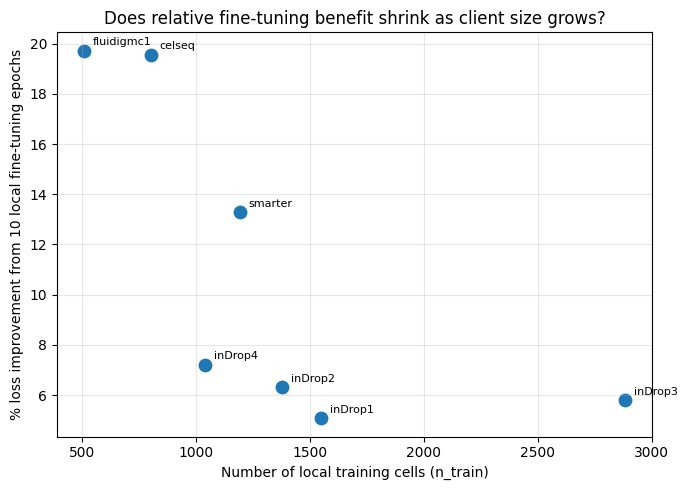

Pearson r (n_train vs. % improvement) = -0.688  (p=0.088, n=7)
Negative r => smaller clients benefit more from local adaptation (consistent with a size-driven fairness gap under standard FedAvg).


In [8]:
last_ft = FT_EPOCHS_TO_TRY[-1]
after_col = f"valid_loss_after_{last_ft}ep"

results_df["pct_improvement_raw"] = (
    100 * (results_df["valid_loss_before"] - results_df[after_col]) / results_df["valid_loss_before"]
)

plot_df = results_df.sort_values("n_train")

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(plot_df["n_train"], plot_df["pct_improvement_raw"], s=80)
for row in plot_df.itertuples():
    label = row.tech[0] if row.tech else row.client_id
    ax.annotate(label, (row.n_train, row.pct_improvement_raw),
                textcoords="offset points", xytext=(6, 4), fontsize=8)

ax.set_xlabel("Number of local training cells (n_train)")
ax.set_ylabel(f"% loss improvement from {last_ft} local fine-tuning epochs")
ax.set_title("Does relative fine-tuning benefit shrink as client size grows?")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

try:
    from scipy.stats import pearsonr
    r, p = pearsonr(plot_df["n_train"], plot_df["pct_improvement_raw"])
    print(f"Pearson r (n_train vs. % improvement) = {r:.3f}  (p={p:.3f}, n={len(plot_df)})")
except ImportError:
    r = np.corrcoef(plot_df["n_train"], plot_df["pct_improvement_raw"])[0, 1]
    print(f"Pearson r (n_train vs. % improvement) = {r:.3f}  (n={len(plot_df)}, scipy unavailable for p-value)")

print("Negative r => smaller clients benefit more from local adaptation "
      "(consistent with a size-driven fairness gap under standard FedAvg).")


In [11]:
def finetune_diagnostic(checkpoint_dir: Path, ft_epochs: int = 10) -> pd.DataFrame:
    """Same procedure as Section 3, refactored into a function so it can be
    run against multiple checkpoints without duplicating the loop."""
    model = scvi.model.SCVI.load(str(checkpoint_dir))
    weights = get_weights(model)
    del model
    gc.collect()

    rows = []
    for client_id in range(N_CLIENTS):
        client_folder = Path(CLIENT_FOLDER_TEMPLATE.format(partition_id=client_id))
        hvg_list = read_json(client_folder / TOP2K_GENES_FILE)
        batch_list = read_json(client_folder / ALL_TECHS_FILE)

        adata_train, adata_valid = load_client_data(client_id, CLIENT_FOLDER_TEMPLATE, hvg_list)
        tech = adata_train.obs["tech"].unique().tolist()

        arch_cfg = get_architecture({})
        m = create_scvi_model(adata_train, batch_list, arch_cfg)
        set_weights(m, weights)

        before = get_loss_metrics(m, adata_valid)
        m.train(max_epochs=ft_epochs, train_size=1.0)
        after = get_loss_metrics(m, adata_valid)

        rows.append({
            "client_id": client_id,
            "tech": tech[0] if tech else client_id,
            "n_train": adata_train.n_obs,
            "n_valid": adata_valid.n_obs,
            "valid_loss_before": before["loss"],
            "valid_loss_after": after["loss"],
            "pct_improvement_raw": 100 * (before["loss"] - after["loss"]) / before["loss"],
        })

        del m, adata_train, adata_valid
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return pd.DataFrame(rows)


# Keep this short -- each entry reruns the full per-client fine-tuning loop.
# Adjust run tags to strategies you actually trained.
STRATEGIES_TO_COMPARE = {
    "FedAvg (baseline, q=0.0)": RESULTS_ROOT / f"{MODEL_FILE_PATH}_qffl_q0p0",
    "q-FFL (q=1.0, norm)":      RESULTS_ROOT / f"{MODEL_FILE_PATH}_qffl_q1p0_norm",
}

comparison_rows = []
for label, ckpt_dir in STRATEGIES_TO_COMPARE.items():
    if not ckpt_dir.exists():
        print(f"[SKIPPED] {label}: checkpoint not found at {ckpt_dir}")
        continue
    df = finetune_diagnostic(ckpt_dir, ft_epochs=last_ft)
    df["strategy"] = label
    comparison_rows.append(df)

comparison_df = pd.concat(comparison_rows, ignore_index=True) if comparison_rows else pd.DataFrame()
comparison_df


INFO     File ..\..\..\fairness_results\model_federated_qffl_q0p0\model.pt already downloaded                      
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


c:\Users\virgi\anaconda3\envs\flwr-scvi\Lib\site-packages\scvi\data\fields\_base_field.py:63: UserWarning: adata.layers[counts] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)
c:\Users\virgi\anaconda3\envs\flwr-scvi\Lib\site-packages\scvi\data\fields\_base_field.py:63: UserWarning: adata.layers[counts] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)
c:\Users\virgi\anaconda3\envs\flwr-scvi\Lib\site-packages\scvi\module\_vae.py:573: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experime

Epoch 1/10:   0%|          | 0/10 [00:00<?, ?it/s]

c:\Users\virgi\anaconda3\envs\flwr-scvi\Lib\site-packages\scvi\module\_vae.py:573: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)


Epoch 2/10:  10%|█         | 1/10 [00:00<00:03,  2.56it/s, v_num=1, train_loss=1.08e+3]

...

Epoch 10/10: 100%|██████████| 10/10 [00:05<00:00,  1.93it/s, v_num=1, train_loss=2.64e+3]

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 10/10: 100%|██████████| 10/10 [00:05<00:00,  1.91it/s, v_num=1, train_loss=2.64e+3]


c:\Users\virgi\anaconda3\envs\flwr-scvi\Lib\site-packages\scvi\module\_vae.py:573: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)


,client_id,tech,n_train,n_valid,valid_loss_before,valid_loss_after,pct_improvement_raw,strategy
0,0,celseq,803,201,1200.574951,981.543396,18.243888,"FedAvg (baseline, q=0.0)"
1,1,fluidigmc1,510,128,5381.075684,4390.034668,18.417154,"FedAvg (baseline, q=0.0)"
2,2,inDrop1,1550,387,584.324829,559.634155,4.225505,"FedAvg (baseline, q=0.0)"
3,3,inDrop2,1379,345,533.503296,505.370819,5.273159,"FedAvg (baseline, q=0.0)"
4,4,inDrop3,2884,721,566.868042,539.812378,4.772833,"FedAvg (baseline, q=0.0)"
5,5,inDrop4,1042,261,660.336243,619.326172,6.210483,"FedAvg (baseline, q=0.0)"
6,6,smarter,1194,298,3110.985840,2722.526123,12.486708,"FedAvg (baseline, q=0.0)"
7,0,celseq,803,201,1189.178101,977.090576,17.834799,"q-FFL (q=1.0, norm)"
8,1,fluidigmc1,510,128,5724.254883,4483.815918,21.669877,"q-FFL (q=1.0, norm)"
9,2,inDrop1,1550,387,576.942505,558.177185,3.252546,"q-FFL (q=1.0, norm)"


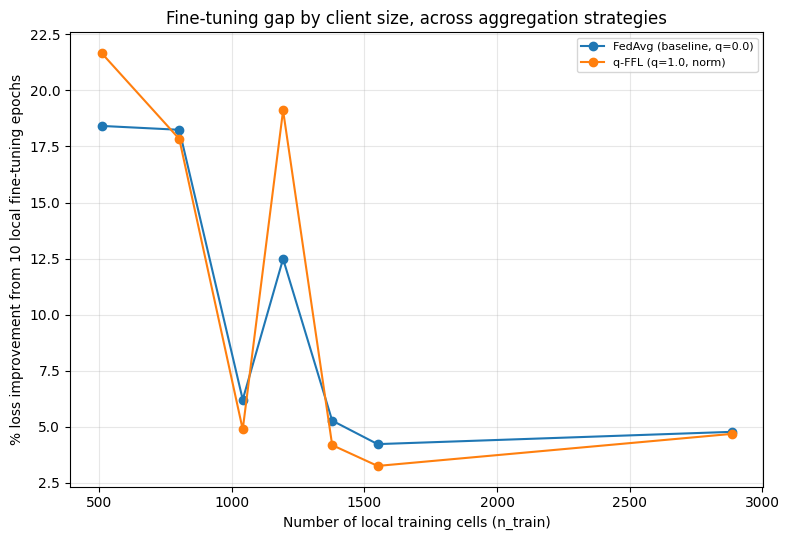

Correlation (n_train vs. % improvement) per strategy -- closer to 0 means
that strategy already closed most of the size-driven personalization gap:

  FedAvg (baseline, q=0.0)            r = -0.689
  q-FFL (q=1.0, norm)                 r = -0.620


In [12]:
if not comparison_df.empty:
    fig, ax = plt.subplots(figsize=(8, 5.5))

    for label, sub in comparison_df.groupby("strategy"):
        sub = sub.sort_values("n_train")
        ax.plot(sub["n_train"], sub["pct_improvement_raw"], marker="o", label=label)

    ax.set_xlabel("Number of local training cells (n_train)")
    ax.set_ylabel(f"% loss improvement from {last_ft} local fine-tuning epochs")
    ax.set_title("Fine-tuning gap by client size, across aggregation strategies")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    print("Correlation (n_train vs. % improvement) per strategy -- closer to 0 means")
    print("that strategy already closed most of the size-driven personalization gap:\n")
    for label, sub in comparison_df.groupby("strategy"):
        r = np.corrcoef(sub["n_train"], sub["pct_improvement_raw"])[0, 1]
        print(f"  {label:35s} r = {r:+.3f}")


## 9. Updated interpretation checklist

- [ ] Is the `n_train` vs. `%improvement` correlation in Section 7 clearly
      negative, or is it weak/noisy given only `N_CLIENTS` data points? With
      this few clients, treat any correlation as suggestive, not proof.
- [ ] In Section 8, does a fairness-motivated strategy (e.g. `q=1.0, norm`)
      show a *weaker* (closer to zero) correlation than the baseline? That
      would mean it's genuinely reducing the personalization gap during
      training, which is a more direct/faithful notion of "fairness fix"
      than matching absolute-loss targets across clients with very different
      intrinsic difficulty.
- [ ] Remember Section 5's finding: Jain's index (absolute normalized loss)
      barely moved after fine-tuning (+0.0017). If Section 7/8 nonetheless
      show a real size-vs-improvement relationship, that's a good discussion
      point for the report: absolute-loss fairness metrics and
      relative-improvement fairness metrics can disagree, and both are worth
      reporting since they answer different questions.
